# 03 — Sélection des variables, modélisation et évaluation

## Objectif

Cette étape vise à construire et évaluer plusieurs modèles capables de prévoir
la consommation électrique de la Nouvelle-Aquitaine à J+1.

L'approche comprend :

- une séparation chronologique des données ;
- la construction de baselines temporelles ;
- l'analyse et la sélection des variables ;
- l'entraînement de plusieurs familles de modèles ;
- la comparaison de leurs performances ;
- l'optimisation du modèle retenu ;
- l'analyse détaillée de ses erreurs.

L'objectif est notamment de vérifier que l'approche Machine Learning apporte
un gain mesurable par rapport à des méthodes de prévision simples.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "nouvelle_aquitaine_ml.parquet"
)

df = pd.read_parquet(DATA_PATH)

df.shape

(130924, 29)

In [2]:
df.columns

Index(['Date - Heure', 'consumption_lag_30min', 'consumption_lag_1h',
       'consumption_lag_3h', 'consumption_lag_6h', 'consumption_lag_24h',
       'consumption_lag_48h', 'consumption_lag_7d', 'consumption_roll_mean_6',
       'consumption_roll_mean_48', 'consumption_roll_mean_336',
       'consumption_roll_std_48', 'hour', 'minute', 'day_of_week', 'month',
       'day_of_year', 'is_weekend', 'half_hour_slot', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'consumption_diff_1',
       'consumption_diff_48', 'target_consumption_t_plus_24h',
       'consumption_t'],
      dtype='str')

In [3]:
df = df.sort_values("Date - Heure").reset_index(drop=True)

df["Date - Heure"].min(), df["Date - Heure"].max()

(Timestamp('2019-01-08 00:00:00+0000', tz='UTC'),
 Timestamp('2026-06-29 21:30:00+0000', tz='UTC'))

In [4]:
train = df[df["Date - Heure"] < "2024-01-01"].copy()

validation = df[
    (df["Date - Heure"] >= "2024-01-01")
    & (df["Date - Heure"] < "2025-01-01")
].copy()

test = df[
    (df["Date - Heure"] >= "2025-01-01")
    & (df["Date - Heure"] < "2026-01-01")
].copy()

In [5]:
for name, subset in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test),
]:
    print(
        name,
        subset.shape,
        subset["Date - Heure"].min(),
        subset["Date - Heure"].max()
    )

Train (87232, 29) 2019-01-08 00:00:00+00:00 2023-12-31 23:30:00+00:00
Validation (17552, 29) 2024-01-01 00:00:00+00:00 2024-12-31 23:30:00+00:00
Test (17504, 29) 2025-01-01 00:00:00+00:00 2025-12-31 23:30:00+00:00


## Séparation temporelle

Les observations ne sont pas réparties aléatoirement entre les jeux
d'entraînement, de validation et de test.

La séparation respecte la chronologie afin de reproduire le fonctionnement
réel du modèle : celui-ci apprend sur des observations passées avant d'être
évalué sur une période future jamais observée pendant l'entraînement.

Le jeu de test est conservé jusqu'à l'évaluation finale et n'est pas utilisé
pour sélectionner le modèle ou ses hyperparamètres.

In [6]:
y_val = validation["target_consumption_t_plus_24h"]

In [7]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(
            y_true,
            y_pred
        ) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

In [8]:
baseline_day = validation["consumption_t"]

baseline_results = regression_metrics(
    y_val,
    baseline_day
)

baseline_results

{'MAE': 278.2608249772106, 'RMSE': 384.6932214871463, 'R2': 0.8494614106901628}

In [9]:
baseline_week = validation["consumption_lag_7d"]

baseline_week_results = regression_metrics(
    y_val,
    baseline_week
)

baseline_week_results

{'MAE': 489.92325660893346, 'RMSE': 683.423052307464, 'R2': 0.5248857878253879}

In [10]:
excluded_cols = [
    "Date - Heure",
    "target_consumption_t_plus_24h",
]

In [11]:
feature_cols = [
    col for col in df.columns
    if col not in excluded_cols
    and pd.api.types.is_numeric_dtype(df[col])
]

correlations = (
    train[feature_cols + ["target_consumption_t_plus_24h"]]
    .corr()["target_consumption_t_plus_24h"]
    .drop("target_consumption_t_plus_24h")
    .sort_values(key=abs, ascending=False)
)

correlations

consumption_t                0.931107
consumption_lag_30min        0.923158
consumption_lag_1h           0.909679
consumption_roll_mean_6      0.890654
consumption_lag_24h          0.864532
consumption_lag_48h          0.836931
consumption_roll_mean_48     0.828805
consumption_lag_3h           0.828417
consumption_roll_mean_336    0.813938
consumption_lag_7d           0.809513
consumption_lag_6h           0.732122
month_cos                    0.607255
month_sin                    0.353941
hour_cos                    -0.260445
day_of_year                 -0.211002
month                       -0.209932
consumption_diff_48          0.175213
consumption_roll_std_48      0.154308
dow_sin                      0.139830
hour                         0.126072
half_hour_slot               0.126047
day_of_week                 -0.117274
dow_cos                      0.098589
is_weekend                  -0.093555
hour_sin                    -0.055555
consumption_diff_1           0.055393
minute      

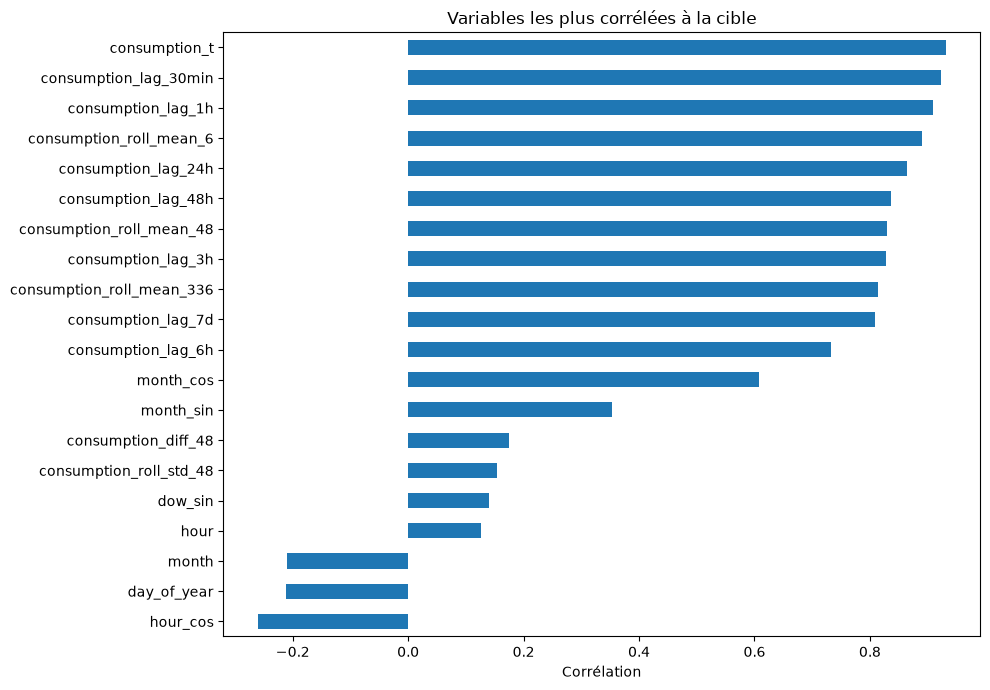

In [12]:
correlations.head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Variables les plus corrélées à la cible")
plt.xlabel("Corrélation")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [14]:
X_train = train[feature_cols]
y_train = train["target_consumption_t_plus_24h"]

X_val = validation[feature_cols]
y_val = validation["target_consumption_t_plus_24h"]

In [15]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_val)

In [16]:
ridge_results = regression_metrics(
    y_val,
    ridge_pred
)

ridge_results

{'MAE': 238.92036003246574,
 'RMSE': 322.67640567818603,
 'R2': 0.8940860425746975}

In [17]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    random_state=42
)

hgb.fit(X_train, y_train)

hgb_pred = hgb.predict(X_val)

hgb_results = regression_metrics(
    y_val,
    hgb_pred
)

hgb_results

{'MAE': 206.39414699408013,
 'RMSE': 294.44021309447885,
 'R2': 0.911811283689513}

In [18]:
results = pd.DataFrame([
    {"model": "Baseline", **baseline_results},
    {"model": "Ridge", **ridge_results},
    {"model": "HistGradientBoosting", **hgb_results},
])

results

,model,MAE,RMSE,R2
0,Baseline,278.260825,384.693221,0.849461
1,Ridge,238.920360,322.676406,0.894086
2,HistGradientBoosting,206.394147,294.440213,0.911811


Le meilleur modèle non optimisé réduit l’erreur absolue moyenne d’environ 26 % par rapport à une prévision naïve basée sur la consommation observée la veille au même créneau.

In [19]:
from sklearn.inspection import permutation_importance

In [21]:
perm_importance = permutation_importance(
    hgb,
    X_val,
    y_val,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

,feature,importance,std
26,consumption_t,624.124451,3.402994
13,day_of_week,57.721486,0.623176
15,day_of_year,39.056203,0.455278
21,dow_cos,28.143503,0.660975
5,consumption_lag_48h,25.985958,0.528661
23,month_cos,15.095210,0.458231
19,hour_cos,12.926603,0.614702
0,consumption_lag_30min,11.624309,0.313365
11,hour,10.083662,0.261618
17,half_hour_slot,8.003777,0.122625


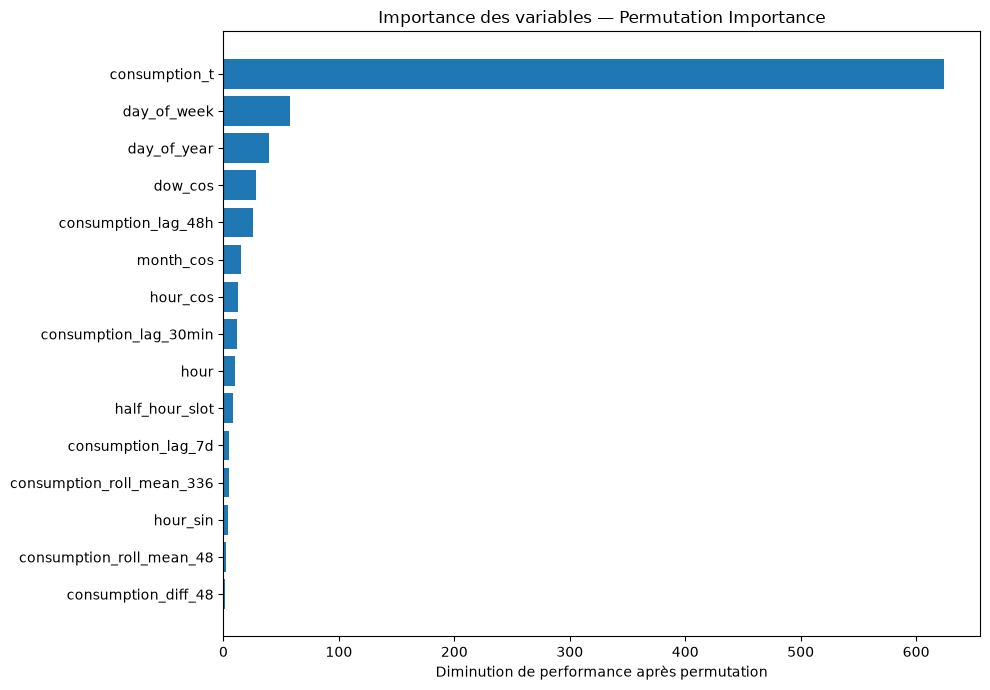

In [22]:
top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Diminution de performance après permutation")
plt.title("Importance des variables — Permutation Importance")

plt.tight_layout()
plt.show()

In [23]:
selected_features = (
    importance_df
    .head(10)["feature"]
    .tolist()
)

selected_features

['consumption_t',
 'day_of_week',
 'day_of_year',
 'dow_cos',
 'consumption_lag_48h',
 'month_cos',
 'hour_cos',
 'consumption_lag_30min',
 'hour',
 'half_hour_slot']

In [24]:
hgb_selected = HistGradientBoostingRegressor(
    random_state=42
)

hgb_selected.fit(
    X_train[selected_features],
    y_train
)

selected_pred = hgb_selected.predict(
    X_val[selected_features]
)

selected_results = regression_metrics(
    y_val,
    selected_pred
)

selected_results

{'MAE': 206.8469985131064, 'RMSE': 294.9069767080272, 'R2': 0.9115314583852682}

In [25]:
selection_comparison = pd.DataFrame([
    {
        "model": "HGB - toutes variables",
        **hgb_results
    },
    {
        "model": "HGB - variables sélectionnées",
        **selected_results
    }
])

selection_comparison

,model,MAE,RMSE,R2
0,HGB - toutes variables,206.394147,294.440213,0.911811
1,HGB - variables sélectionnées,206.846999,294.906977,0.911531


La sélection par permutation importance a permis de retenir les 10 variables les plus contributives. Le modèle réduit ainsi fortement le nombre de variables exploitées tout en conservant des performances quasi identiques : la MAE passe de 206,39 MW à 206,85 MW et le R² de 0,9118 à 0,9115. Cette sélection permet donc de simplifier le modèle sans dégradation significative de sa capacité prédictive.
réduction de plus de 60 % du nombre de variables

In [26]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor

In [27]:
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]

In [28]:
tscv = TimeSeriesSplit(
    n_splits=4,
    gap=48
)

Une zone tampon de 24 heures a été ajoutée entre entraînement et validation afin d'empêcher la cible future des dernières observations d'entraînement de chevaucher temporellement la période de validation

In [29]:
param_distributions = {
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_iter": [100, 200, 300],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 40, 60],
    "l2_regularization": [0.0, 0.1, 1.0, 5.0],
}

In [30]:
search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(
        random_state=42
    ),
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [31]:
search.fit(
    X_train_selected,
    y_train
)

Fitting 4 folds for each of 30 candidates, totalling 120 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'l2_regularization': [0.0, 0.1, ...], 'learning_rate': [0.03, 0.05, ...], 'max_iter': [100, 200, ...], 'max_leaf_nodes': [15, 31, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best

In [32]:
search.best_params_

{'min_samples_leaf': 60,
 'max_leaf_nodes': 15,
 'max_iter': 200,
 'learning_rate': 0.03,
 'l2_regularization': 5.0}

In [33]:
-search.best_score_

np.float64(221.23073897138693)

In [34]:
best_hgb = search.best_estimator_

optimized_pred = best_hgb.predict(
    X_val_selected
)

optimized_results = regression_metrics(
    y_val,
    optimized_pred
)

optimized_results

{'MAE': 205.09516703034458, 'RMSE': 289.671339051694, 'R2': 0.9146448306954541}

In [35]:
optimization_comparison = pd.DataFrame([
    {
        "model": "HGB sélectionné - défaut",
        **selected_results
    },
    {
        "model": "HGB sélectionné - optimisé",
        **optimized_results
    }
])

optimization_comparison

,model,MAE,RMSE,R2
0,HGB sélectionné - défaut,206.846999,294.906977,0.911531
1,HGB sélectionné - optimisé,205.095167,289.671339,0.914645


In [36]:
mae_gain = (
    selected_results["MAE"]
    - optimized_results["MAE"]
) / selected_results["MAE"] * 100

rmse_gain = (
    selected_results["RMSE"]
    - optimized_results["RMSE"]
) / selected_results["RMSE"] * 100

print(f"Gain MAE : {mae_gain:.2f} %")
print(f"Gain RMSE : {rmse_gain:.2f} %")

Gain MAE : 0.85 %
Gain RMSE : 1.78 %


## Optimisation du modèle

Le modèle HistGradientBoosting retenu après comparaison a été optimisé à l'aide
d'une recherche aléatoire d'hyperparamètres.

La validation croisée respecte l'ordre temporel des observations grâce à
`TimeSeriesSplit`.

Les principaux hyperparamètres étudiés sont :

- le taux d'apprentissage ;
- le nombre maximal d'itérations ;
- le nombre maximal de feuilles ;
- le nombre minimal d'observations par feuille ;
- la régularisation L2.

L'objectif est d'améliorer les performances sans augmenter inutilement
la complexité du modèle.

L’optimisation des hyperparamètres apporte un gain limité, ce qui indique que les paramètres par défaut du HistGradientBoosting sont déjà adaptés à ce jeu de données. L’optimisation a néanmoins permis de vérifier expérimentalement ce point et d’identifier une configuration légèrement plus performante.

In [37]:
X_test_selected = test[selected_features]
y_test = test["target_consumption_t_plus_24h"]

test_pred = best_hgb.predict(X_test_selected)

test_results = regression_metrics(
    y_test,
    test_pred
)

test_results

{'MAE': 208.76847285581667,
 'RMSE': 287.5997532043663,
 'R2': 0.9248180117746249}

In [38]:
baseline_test_pred = test["consumption_t"]

baseline_test_results = regression_metrics(
    y_test,
    baseline_test_pred
)

pd.DataFrame([
    {
        "model": "Baseline J-1",
        **baseline_test_results
    },
    {
        "model": "HGB optimisé",
        **test_results
    }
])

,model,MAE,RMSE,R2
0,Baseline J-1,257.927388,356.445557,0.884516
1,HGB optimisé,208.768473,287.599753,0.924818


In [39]:
mae_gain_test = (
    baseline_test_results["MAE"]
    - test_results["MAE"]
) / baseline_test_results["MAE"] * 100

rmse_gain_test = (
    baseline_test_results["RMSE"]
    - test_results["RMSE"]
) / baseline_test_results["RMSE"] * 100

print(f"Gain MAE sur test : {mae_gain_test:.2f} %")
print(f"Gain RMSE sur test : {rmse_gain_test:.2f} %")

Gain MAE sur test : 19.06 %
Gain RMSE sur test : 19.31 %


In [40]:
test_results_df = test[
    ["Date - Heure"]
].copy()

test_results_df["y_true"] = y_test.values
test_results_df["y_pred"] = test_pred
test_results_df["error"] = (
    test_results_df["y_true"]
    - test_results_df["y_pred"]
)

test_results_df["abs_error"] = (
    test_results_df["error"].abs()
)

In [41]:
test_results_df["abs_error"].describe()

count    17504.000000
mean       208.768473
std        197.817033
min          0.058255
25%         68.494267
50%        150.408683
75%        284.118957
max       1509.786936
Name: abs_error, dtype: float64

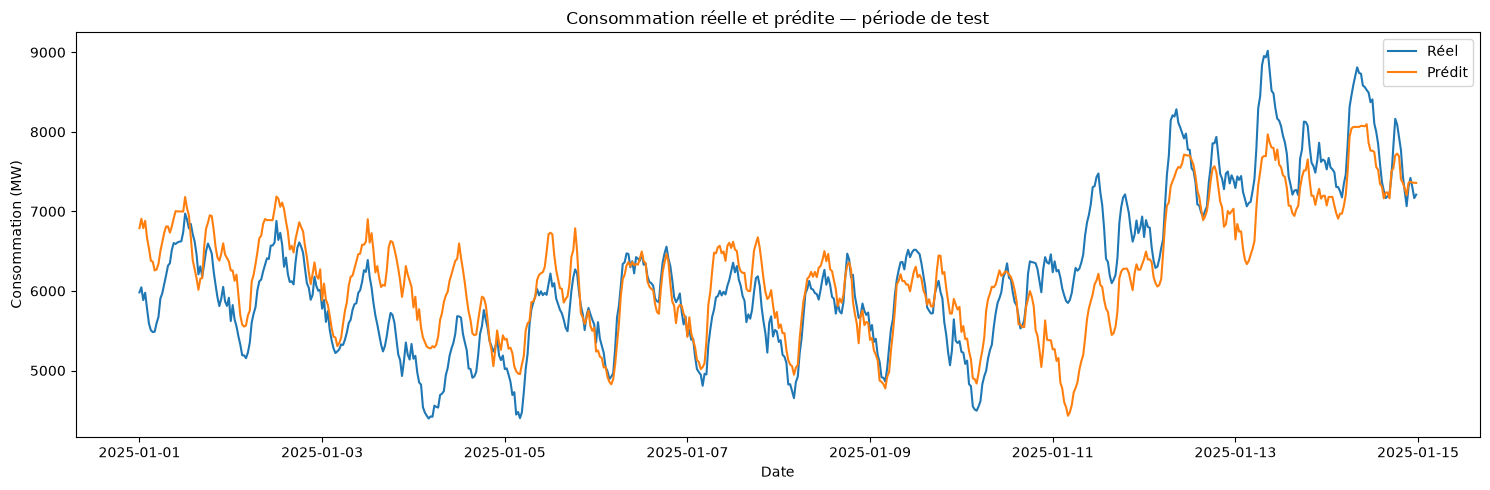

In [42]:
sample_period = test_results_df[
    (test_results_df["Date - Heure"] >= "2025-01-01")
    & (test_results_df["Date - Heure"] < "2025-01-15")
]

plt.figure(figsize=(15, 5))

plt.plot(
    sample_period["Date - Heure"],
    sample_period["y_true"],
    label="Réel"
)

plt.plot(
    sample_period["Date - Heure"],
    sample_period["y_pred"],
    label="Prédit"
)

plt.title("Consommation réelle et prédite — période de test")
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.tight_layout()
plt.show()

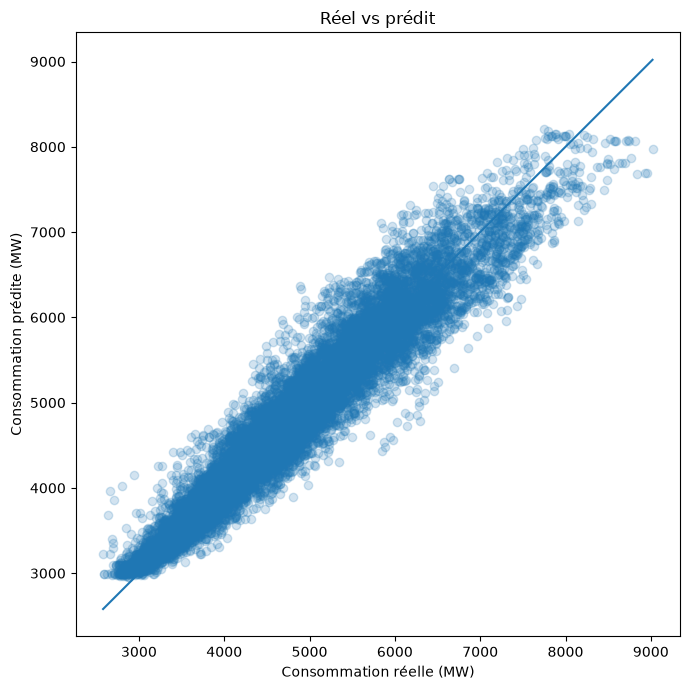

In [43]:
plt.figure(figsize=(7, 7))

plt.scatter(
    test_results_df["y_true"],
    test_results_df["y_pred"],
    alpha=0.2
)

min_val = min(
    test_results_df["y_true"].min(),
    test_results_df["y_pred"].min()
)

max_val = max(
    test_results_df["y_true"].max(),
    test_results_df["y_pred"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.xlabel("Consommation réelle (MW)")
plt.ylabel("Consommation prédite (MW)")
plt.title("Réel vs prédit")
plt.tight_layout()
plt.show()

In [44]:
threshold = y_test.quantile(0.90)

high_consumption = test_results_df[
    test_results_df["y_true"] >= threshold
]

high_consumption_metrics = regression_metrics(
    high_consumption["y_true"],
    high_consumption["y_pred"]
)

high_consumption_metrics

{'MAE': 376.7969535997859,
 'RMSE': 459.1069818909505,
 'R2': 0.25478418329746577}

## Évaluation finale

Le modèle sélectionné et optimisé a été évalué sur une période de test
chronologiquement postérieure aux données utilisées pour l'entraînement
et la sélection des hyperparamètres.

Cette période n'a pas été utilisée lors du développement du modèle.

Les performances ont été comparées à une baseline temporelle simple afin
de mesurer la valeur ajoutée réelle du Machine Learning.

Une analyse complémentaire des erreurs a également été réalisée sur les
périodes de forte consommation afin de vérifier la robustesse du modèle
dans les situations les plus importantes d'un point de vue métier.

### Expérimentation

Tester un modèle de prédiction à J+7

In [45]:
train_final = pd.concat(
    [train, validation],
    ignore_index=True
)

X_train_final = train_final[selected_features]
y_train_final = train_final["target_consumption_t_plus_24h"]

In [46]:
final_model = HistGradientBoostingRegressor(
    **search.best_params_,
    random_state=42
)

final_model.fit(
    X_train_final,
    y_train_final
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.03
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",60
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",5.0
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [49]:
from pathlib import Path
import joblib
import json

In [48]:
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = (
    ARTIFACTS_DIR
    / "electricity_consumption_hgb_j1.joblib"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

MODEL_PATH

WindowsPath('c:/Users/audrencorre/OneDrive - GROUPE BERNARD/Documents/RNCP_BLOC_5/artifacts/electricity_consumption_hgb_j1.joblib')

In [50]:
metadata = {
    "model_name": "HistGradientBoostingRegressor",
    "version": "1.0.0",

    "region": "Nouvelle-Aquitaine",
    "forecast_horizon": "24h",

    "target": "target_consumption_t_plus_24h",

    "features": selected_features,

    "hyperparameters": search.best_params_,

    "test_metrics": {
        "MAE": float(test_results["MAE"]),
        "RMSE": float(test_results["RMSE"]),
        "R2": float(test_results["R2"]),
    },

    "baseline_test_metrics": {
        "MAE": float(baseline_test_results["MAE"]),
        "RMSE": float(baseline_test_results["RMSE"]),
        "R2": float(baseline_test_results["R2"]),
    },

    "training_period_end": "2024-12-31",
    "test_period": "2025"
}

In [51]:
METADATA_PATH = (
    ARTIFACTS_DIR
    / "electricity_consumption_hgb_j1_metadata.json"
)

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

In [52]:
loaded_model = joblib.load(
    MODEL_PATH
)

In [75]:
sample = test[
    selected_features
].iloc[[10]]

sample

,consumption_t,day_of_week,day_of_year,dow_cos,consumption_lag_48h,month_cos,hour_cos,consumption_lag_30min,hour,half_hour_slot
104794,6287.0,2,1,-0.222521,5691.0,0.866025,0.258819,6238.0,5,10


In [76]:
prediction = loaded_model.predict(
    sample
)

prediction

array([6351.14266612])

In [77]:
actual = test[
    "target_consumption_t_plus_24h"
].iloc[0]

print(
    f"Prévision : {prediction[0]:.0f} MW"
)

print(
    f"Valeur réelle : {actual:.0f} MW"
)

Prévision : 6351 MW
Valeur réelle : 5982 MW


In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment(
    "electricity_consumption_j1"
)

with mlflow.start_run():

    mlflow.log_params(
        search.best_params_
    )

    mlflow.log_metrics({
        "mae_test": test_results["MAE"],
        "rmse_test": test_results["RMSE"],
        "r2_test": test_results["R2"],
    })

    mlflow.sklearn.log_model(
        final_model,
        name="model"
    )